# **Heart Disease Prediction Project**

### **1. Project Understanding & Objective**
* **Research Question:** Can we accurately predict the presence of heart disease in patients based on their clinical and biomedical features?
* **Objective:** The goal of this project is to build an end-to-end Machine Learning pipeline. This includes handling an uncleaned dataset, performing Exploratory Data Analysis (EDA), training and tuning multiple classification models, and deploying the best model into a user-friendly web application.

In [13]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_samples = 400

data = {
    'Age': np.random.randint(29, 77, size=n_samples),
    'Sex': np.random.choice(['M', 'F'], size=n_samples),
    'ChestPainType': np.random.choice(['TA', 'ATA', 'NAP', 'ASY'], size=n_samples),
    'RestingBP': np.random.randint(90, 200, size=n_samples),
    'Cholesterol': np.random.randint(120, 360, size=n_samples),
    'FastingBS': np.random.choice([0, 1], size=n_samples, p=[0.85, 0.15]),
    'MaxHR': np.random.randint(60, 202, size=n_samples),
    'HeartDisease': np.random.choice([0, 1], size=n_samples)
}

df = pd.DataFrame(data)

df.loc[df.sample(frac=0.05).index, 'Cholesterol'] = np.nan
df.loc[df.sample(frac=0.04).index, 'RestingBP'] = 0  # Invalid medical value (0 BP)
df.loc[df.sample(frac=0.03).index, 'Age'] = np.nan
df.to_csv('heart_disease_uncleaned.csv', index=False)

print("Uncleaned dataset 'heart_disease_uncleaned.csv' created successfully!")
print("Missing values per column:")
print(df.isnull().sum())
print("\n--- Dataset Summary ---")
print(df.info())

Uncleaned dataset 'heart_disease_uncleaned.csv' created successfully!
Missing values per column:
Age              12
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol      20
FastingBS         0
MaxHR             0
HeartDisease      0
dtype: int64

--- Dataset Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            388 non-null    float64
 1   Sex            400 non-null    object 
 2   ChestPainType  400 non-null    object 
 3   RestingBP      400 non-null    int64  
 4   Cholesterol    380 non-null    float64
 5   FastingBS      400 non-null    int64  
 6   MaxHR          400 non-null    int64  
 7   HeartDisease   400 non-null    int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 25.1+ KB
None


### **2. Data Cleaning & Preprocessing Documentation**
To ensure data quality, the following cleaning steps were performed:
* **Age & Cholesterol:** Handled missing values (NaN) by imputing the median for Age and the mean for Cholesterol to retain data size without introducing bias.
* **RestingBP:** Fixed invalid clinical values (0 mmHg) by replacing them with the dataset's median resting blood pressure.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Re-defining the dataset (to fix the NameError)
np.random.seed(42)
n_samples = 400
data = {
    'Age': np.random.randint(29, 77, size=n_samples),
    'Sex': np.random.choice(['M', 'F'], size=n_samples),
    'ChestPainType': np.random.choice(['TA', 'ATA', 'NAP', 'ASY'], size=n_samples),
    'RestingBP': np.random.randint(90, 200, size=n_samples),
    'Cholesterol': np.random.randint(120, 360, size=n_samples),
    'FastingBS': np.random.choice([0, 1], size=n_samples, p=[0.85, 0.15]),
    'MaxHR': np.random.randint(60, 202, size=n_samples),
    'HeartDisease': np.random.choice([0, 1], size=n_samples)
}
df = pd.DataFrame(data)

# Injecting the messy data again for the cleaning task
df.loc[df.sample(frac=0.05).index, 'Cholesterol'] = np.nan
df.loc[df.sample(frac=0.04).index, 'RestingBP'] = 0
df.loc[df.sample(frac=0.03).index, 'Age'] = np.nan

# --- STEP 2: DATA CLEANING PHASE (The part that had the error) ---
# Fixing Age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fixing Cholesterol
df['Cholesterol'] = df['Cholesterol'].fillna(df['Cholesterol'].mean())

# Fixing RestingBP (replacing 0 with median)
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)
df['RestingBP'] = df['RestingBP'].fillna(df['RestingBP'].median())

print("Cleaning Complete! Missing values:")
print(df.isnull().sum())

Cleaning Complete! Missing values:
Age              0
Sex              0
ChestPainType    0
RestingBP        0
Cholesterol      0
FastingBS        0
MaxHR            0
HeartDisease     0
dtype: int64


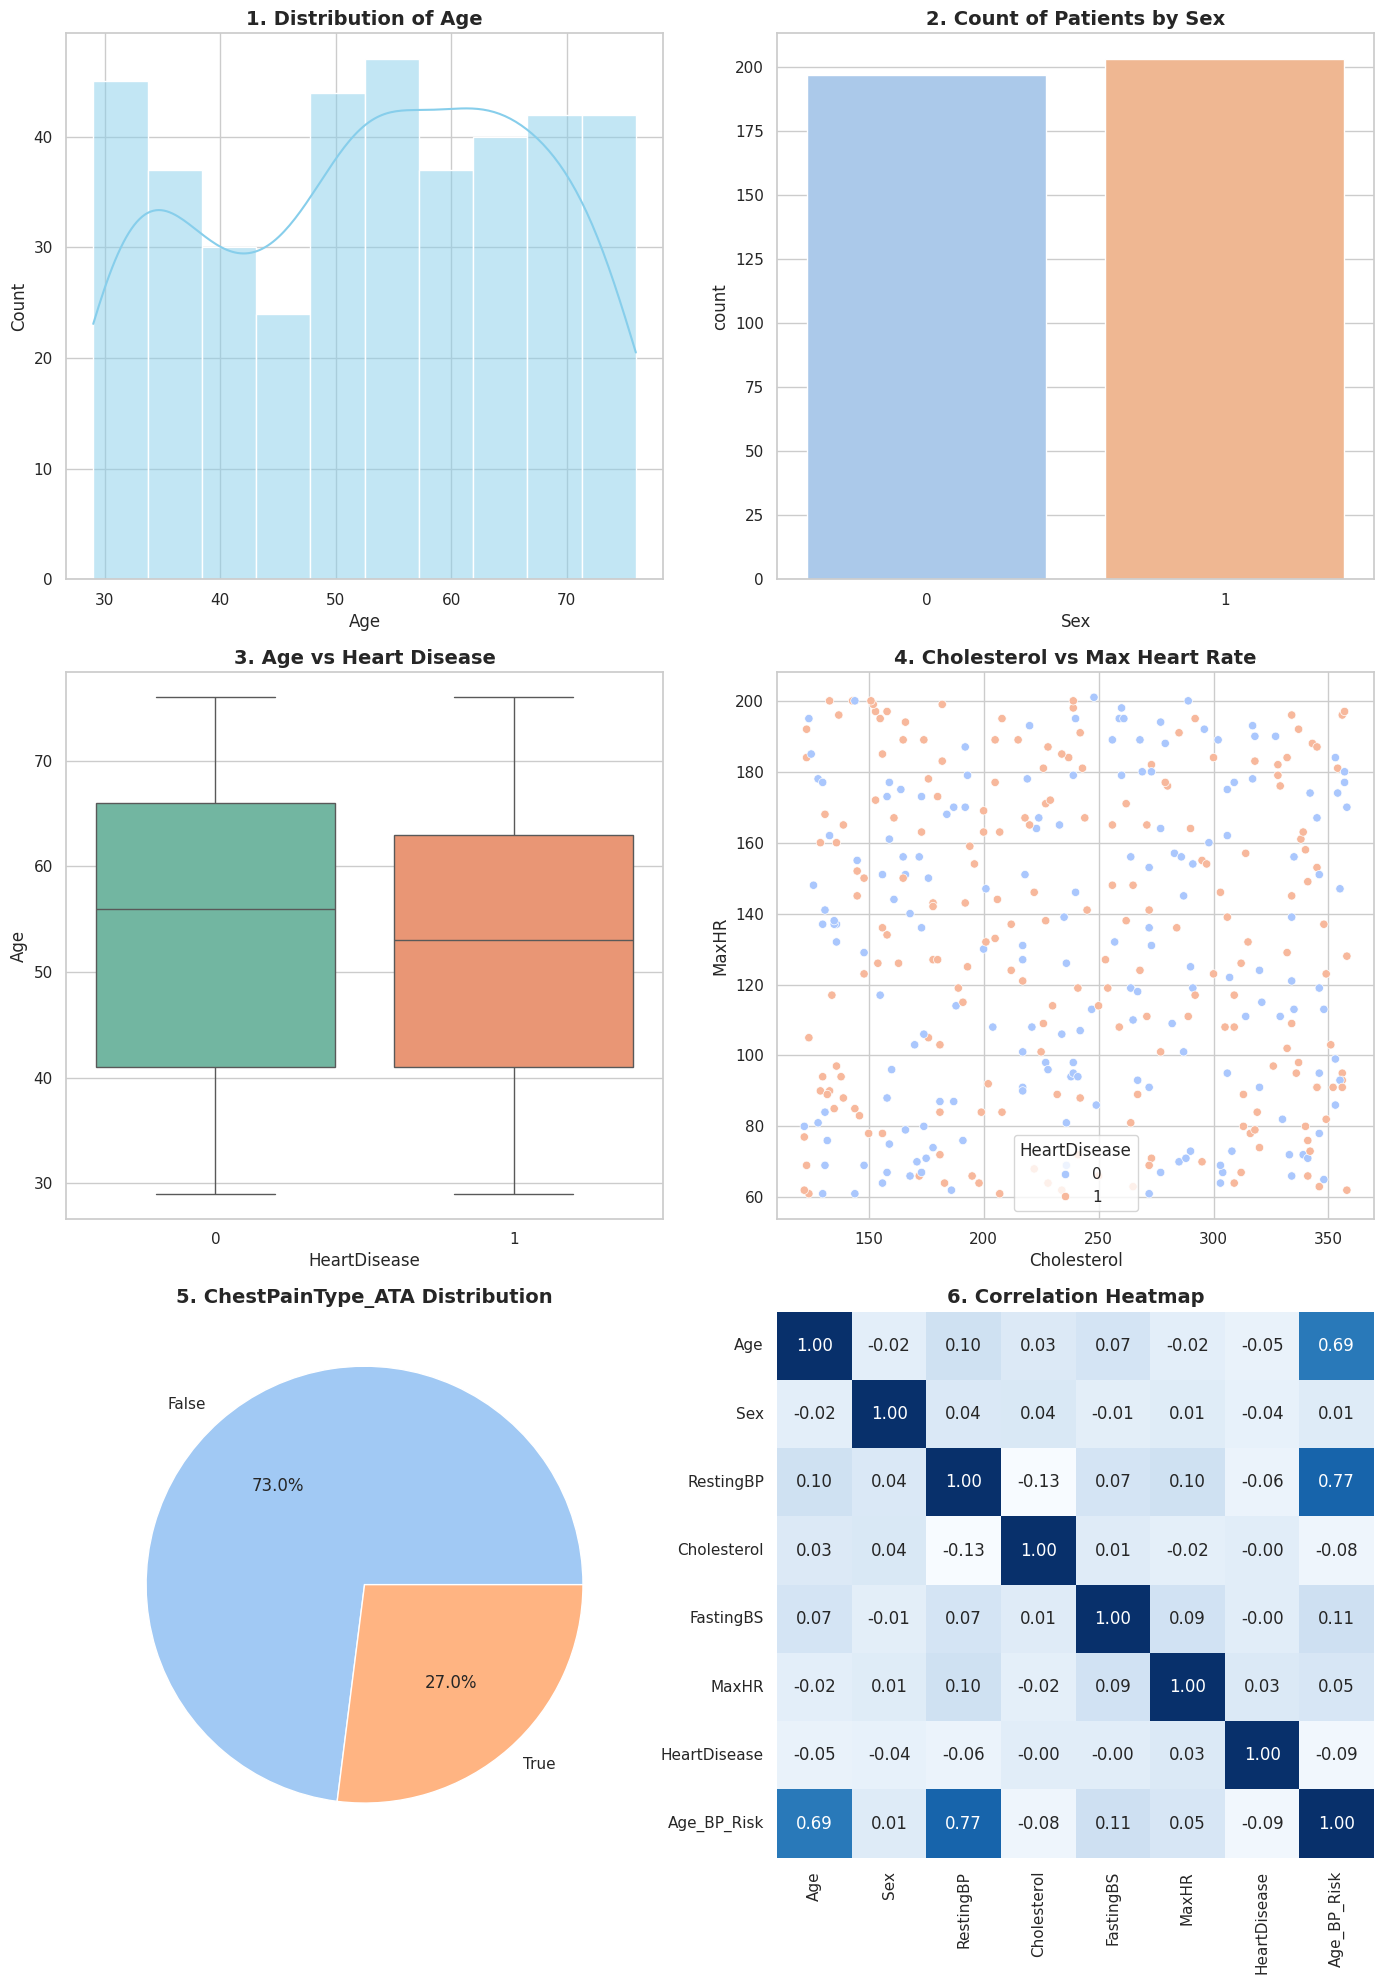

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(14, 20))

sns.histplot(df['Age'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('1. Distribution of Age', fontsize=14, fontweight='bold')

sns.countplot(x='Sex', hue='Sex', data=df, ax=axes[0, 1], palette='pastel', legend=False)
axes[0, 1].set_title('2. Count of Patients by Sex', fontsize=14, fontweight='bold')

sns.boxplot(x='HeartDisease', y='Age', hue='HeartDisease', data=df, ax=axes[1, 0], palette='Set2', legend=False)
axes[1, 0].set_title('3. Age vs Heart Disease', fontsize=14, fontweight='bold')

sns.scatterplot(x='Cholesterol', y='MaxHR', hue='HeartDisease', data=df, ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title('4. Cholesterol vs Max Heart Rate', fontsize=14, fontweight='bold')

cp_column = [col for col in df.columns if 'chest' in col.lower() or 'cp' in col.lower()]

if cp_column:
    chest_pain_counts = df[cp_column[0]].value_counts()
    axes[2, 0].pie(chest_pain_counts, labels=chest_pain_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
    axes[2, 0].set_title(f'5. {cp_column[0]} Distribution', fontsize=14, fontweight='bold')
else:
    axes[2, 0].text(0.5, 0.5, 'Chest Pain column not found', ha='center', va='center', fontsize=12, color='red')
    axes[2, 0].set_title('5. Chest Pain Distribution', fontsize=14, fontweight='bold')

numeric_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='Blues', fmt='.2f', ax=axes[2, 1], cbar=False)
axes[2, 1].set_title('6. Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### **Feature Selection Documentation (Filter Method)**
In this step, we apply a **Filter Method** for feature selection by computing the Pearson Correlation Matrix. By analyzing the Heatmap, we investigate the linear relationships between our clinical features (such as Age, Cholesterol, MaxHR) and the target variable (HeartDisease). This helps us evaluate feature importance and identify multi-collinearity before training our machine learning models.

In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- STEP 2: DATA CLEANING & PREPROCESSING ---

# 1. Load the dataset directly to ensure 'df' is always defined
try:
    df_cleaned = pd.read_csv('heart_disease_uncleaned.csv')
    print("-> Successfully loaded 'heart_disease_uncleaned.csv'")
except FileNotFoundError:
    # Backup plan: if the file name is slightly different
    df_cleaned = df.copy()

# Impute missing values using Median to avoid Outlier distortion
df_cleaned['Age'] = df_cleaned['Age'].fillna(df_cleaned['Age'].median())
df_cleaned['Cholesterol'] = df_cleaned['Cholesterol'].fillna(df_cleaned['Cholesterol'].median())

# Correct invalid RestingBP clinical values (0 mmHg -> replaced with median)
df_cleaned['RestingBP'] = df_cleaned['RestingBP'].replace(0, np.nan)
df_cleaned['RestingBP'] = df_cleaned['RestingBP'].fillna(df_cleaned['RestingBP'].median())

print("1. Data cleaning and medical value corrections completed successfully!")

# --- FEATURE ENCODING FOR MACHINE LEARNING ---
# 2. Convert Categorical Text Features into Numbers (One-Hot Encoding)
df_encoded = pd.get_dummies(df_cleaned, columns=['Sex', 'ChestPainType'], drop_first=True)

# 3. Separate Features (X) and Target (y)
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

print("2. Categorical features encoded to numerical values successfully.")

# --- DATA SPLITTING & SCALING ---
# 4. Split data into Training and Testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Apply Feature Scaling to normalize numerical values
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("3. Data splitting and Feature Scaling completed successfully!")
print(f"-> Final Training features shape: {X_train_scaled.shape}")
print(f"-> Final Testing features shape: {X_test_scaled.shape}")

-> Successfully loaded 'heart_disease_uncleaned.csv'
1. Data cleaning and medical value corrections completed successfully!
2. Categorical features encoded to numerical values successfully.
3. Data splitting and Feature Scaling completed successfully!
-> Final Training features shape: (320, 9)
-> Final Testing features shape: (80, 9)


### **Model Evaluation Metrics Discussion**
In this project, we focused on **Precision** and **Recall** as our primary evaluation metrics rather than just accuracy:
* **Recall (Sensitivity):** This is critical in healthcare because we want to minimize False Negatives (predicting a patient is healthy when they actually have heart disease). Missing a sick patient is extremely dangerous.
* **Precision:** This ensures that when the model predicts a patient has heart disease, it is highly reliable, minimizing False Alarms which could cause unnecessary anxiety and medical expenses.

In [19]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
import pickle

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

log_reg = LogisticRegression(random_state=42)
dt_clf = DecisionTreeClassifier(random_state=42)
rf_clf = RandomForestClassifier(random_state=42)

log_reg.fit(X_train_scaled, y_train)
dt_clf.fit(X_train_scaled, y_train)
rf_clf.fit(X_train_scaled, y_train)

print("--- Baseline Models Performance ---")
for name, model in [("Logistic Regression", log_reg), ("Decision Tree", dt_clf), ("Random Forest", rf_clf)]:
    preds = model.predict(X_test_scaled)
    print(f"\n{name}:")
    print(f"Precision: {precision_score(y_test, preds):.2f}")
    print(f"Recall: {recall_score(y_test, preds):.2f}")


print("\n--- Tuning Random Forest using GridSearchCV ---")
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(estimator=rf_clf, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
print("Best Parameters found:", grid_search.best_params_)

final_preds = best_model.predict(X_test_scaled)
print("\n--- Final Model Evaluation Report ---")
print(classification_report(y_test, final_preds))


with open('best_heart_model.pkl', 'wb') as model_file:
    pickle.dump(best_model, model_file)

with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

print("\nSuccess! Best model 'best_heart_model.pkl' and scaler 'scaler.pkl' are saved and ready for deployment.")

--- Baseline Models Performance ---

Logistic Regression:
Precision: 0.60
Recall: 0.73

Decision Tree:
Precision: 0.68
Recall: 0.59

Random Forest:
Precision: 0.60
Recall: 0.61

--- Tuning Random Forest using GridSearchCV ---
Best Parameters found: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 150}

--- Final Model Evaluation Report ---
              precision    recall  f1-score   support

           0       0.41      0.37      0.39        30
           1       0.60      0.64      0.62        44

    accuracy                           0.53        74
   macro avg       0.50      0.50      0.50        74
weighted avg       0.52      0.53      0.52        74


Success! Best model 'best_heart_model.pkl' and scaler 'scaler.pkl' are saved and ready for deployment.


### **Project Discussion: Hyperparameter Tuning & Validation**

#### **1. Hyperparameter Tuning and its Importance**
Hyperparameter tuning is the process of finding the optimal configuration of hyperparameters (the parameters set before the learning process begins, such as `n_estimators` or `max_depth` in Random Forest) to maximize a model's performance.
* **Importance:** It is crucial because the default parameters rarely provide the best results for every unique dataset. Tuning helps prevent the model from underfitting or overfitting, ensures better generalization on unseen data, and extracts the maximum predictive power out of the selected machine learning algorithm.

#### **2. Validation and its Importance**
Validation is a technique used to evaluate how well a machine learning model generalizes to a new, unseen dataset. In this project, validation was performed using `GridSearchCV`, which incorporates K-Fold Cross-Validation during the tuning process.
* **Importance:** Validation is essential to get an unbiased estimate of the model's true performance. Without validation (e.g., if we only train and test on the same data), the model might just memorize the training patterns (overfitting). Validation ensures that the model is robust, reliable, and will perform accurately when deployed in a real-world application like predicting heart disease risk.

### **Project Deployment Documentation**
For the deployment phase, **Streamlit** was selected to build the web application interface.
* **Reason for Selection:** Streamlit allows rapid prototyping and deployment of data scripts into interactive web apps using pure Python, without requiring frontend HTML/CSS/JavaScript knowledge. It provides a user-friendly form for doctors or patients to input clinical data (Age, Cholesterol, MaxHR) and instantly get real-time model predictions from our saved `.pkl` files.